## Dataset

| x₀ | x₁ (CGPA) | x₂ (IQ) | y (Placed) |
|---:|----------:|---------:|-----------:|
| 1 | 7.5 | 61  | 1 |
| 1 | 8.9 | 109 | 1 |
| 1 | 7.0 | 81  | 0 |

## General Equation
Ax+By+C=0
$
w_0=C,w_1=A,w_2=B\\
w_0X_0+w_1x_1+w_2x_2=0\\
$
$
\sum_{i=1}^{i=n}(w_ix_i)=0
$

- If it is >0 then the model will predict that the he will pe placed and not if it is less than 0

- we will decide a learning rate and eita
- we will run a for loop in epchs and then we will select the random student from it
-  if the row that belongs to the negative region and model predict it to be positive then we will update the coefficents
- $w_\text{new} = w_\text{old}-ȠX_i$
- if  row belongs to the positive region and the model predicts it to be negative then also we will have  to update the value 
- $w_\text{new} = w_\text{old}+ȠX_i$

### This was a bit difficult to check for two different cases instead we can simplify it as 


|$Y_i$|$\hat{y}$|$y_i-\hat{y}$|
----|-------|----------------|
1|1|0|
0|0|0
1|0|1
0|1|-1



### The updated Algorithm is

$
w_n = w_o +\eta(y_i-\hat{y})x_i
$

In [ ]:
""""for i range(epochs):
    select a random student
    Update the student"""

'"for i range(epochs):\n    select a random student\n    Update the student'

In [ ]:
from sklearn.datasets import make_classification
import numpy as np

In [ ]:
X,y= make_classification(n_samples=200,n_features=2,n_informative=1,n_redundant=0,n_clusters_per_class=1,n_classes=2,random_state=6)

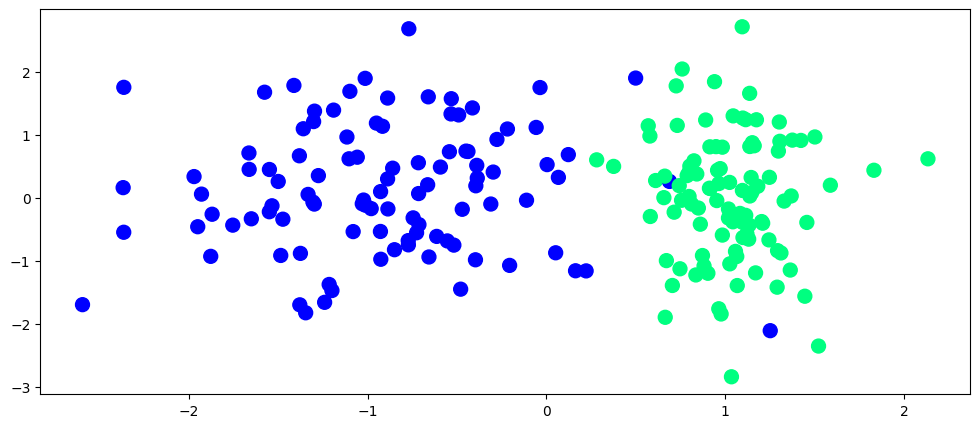

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.show()

In [ ]:
def step(z):
    if(z>0):
        return 1
    else:
        return 0

In [ ]:

def perceptron(X,y):
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    for i in range(1000):
        j = np.random.randint(0,200)
        # we have a step function that retuns 1 if the number is greater thea 0 and retuen 1 if the  number id s less than 1
        y_hat =  step(np.dot(X[j],weights))
        weights = weights-lr*(y[j]-y_hat)*X[j]
    return weights[0],weights[1:]

      



In [ ]:
intercept_,coeff_ = perceptron(X,y)
print(intercept_)
print(coeff_)

11.699999999999976
[-87.05463027  11.556367  ]


- we know that Ax+By+c=0
- y = -A/Bx-c/b
- m is -A/B and c is - C/B

In [ ]:
m = -coeff_[0]/coeff_[1]
c = -intercept_/coeff_[1]

In [ ]:
## for drawing a line with the given m and interceptt then what we do is that we randomely select 100 number then predicts its output then plot them
X_input = np.linspace(-1,1,200)
y_input  = m*X_input+c

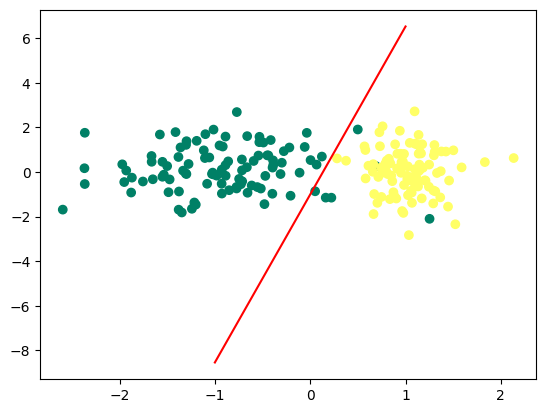

In [ ]:
plt.scatter(X[:,0],X[:,1],c=y,cmap='summer')
plt.plot(X_input,y_input,color='red')
plt.show()

In [ ]:

def perceptronAnimation(X,y):
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    plt.scatter(X[:,1],X[:,2],c=y,cmap='summer')
    for i in range(1000):
        j = np.random.randint(0,200)
        # we have a step function that retuns 1 if the number is greater thea 0 and retuen 1 if the  number id s less than 1
        y_hat =  step(np.dot(X[j],weights))
        weights = weights-lr*(y[j]-y_hat)*X[j]
        coeff_ = weights[1:]
        intercept_ = weights[0]
        m = -coeff_[0]/coeff_[1]
        c = -intercept_/coeff_[1]
        X_input = np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200)
        y_input  = m*X_input+c
        plt.cla()
        plt.scatter(X[:,1], X[:,2], c=y, cmap='summer')
        plt.plot(X_input,y_input,color='red')
        from IPython.display import clear_output

        plt.pause(0.05)
        clear_output(wait=True)
   

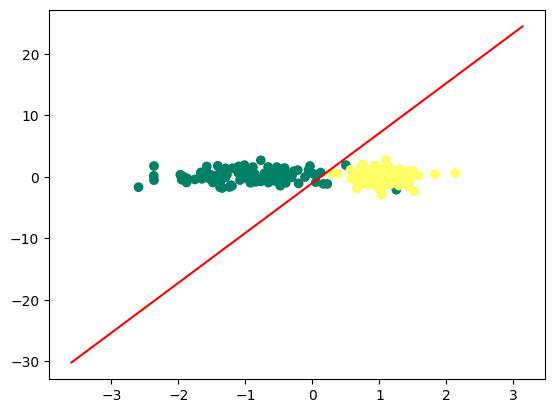

In [ ]:
perceptronAnimation(X,y)

In [ ]:
X,y= make_classification(n_samples=200,n_features=2,n_informative=1,n_redundant=0,n_clusters_per_class=1,n_classes=2,random_state=6,class_sep=3)

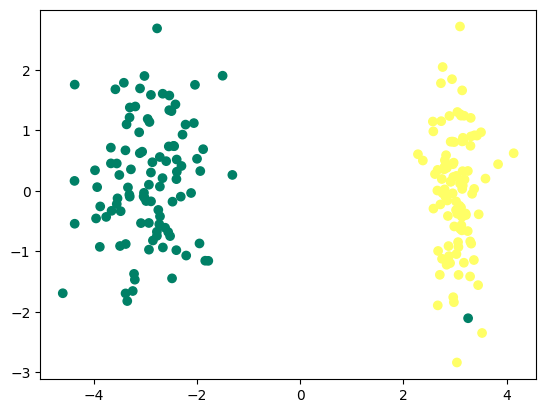

In [ ]:
plt.scatter(X[:,0],X[:,1],c=y,cmap='summer')

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
intercept_sk = model.intercept_
coeff_sk  = model.coef_[0]

In [ ]:
coeff_sk

array([1.86525344, 0.72783608])

In [ ]:
m_sk = -coeff_sk[0]/coeff_sk[1]
c_sk = -intercept_sk/coeff_sk[1]

In [ ]:
X_input = np.linspace(X.min()-1,X.max()-1,100)
y_input = m_sk*X_input+c_sk

In [ ]:
X_input = np.linspace(-1,1,200)
y_input  = m*X_input+c

In [ ]:
X_input_sk = np.linspace(-1,1,200)
y_input_sk  = m_sk*X_input+c_sk

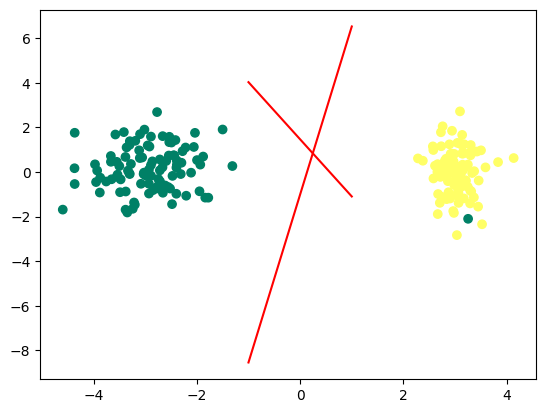

In [ ]:
plt.scatter(X[:,0],X[:,1],c=y,cmap='summer')
plt.plot(X_input,y_input,color = 'red')
plt.plot(X_input_sk,y_input_sk,color = 'red')


### This was not  working fine because this was not the best fit the  other approach that is used in the actual Sklearn library is that all of the correct points pushes  the line so even if it is correct then the line will be push till the equlibrium

- ### The Ma#gnitude of push and pull depends on the  distnance from the line ###
- ### The main problem was that when we were uisng the step function the the output was 0 or 1 and the given  output was also 0 and 1 so we need something so that the output is different so we use the sigmoid function ###

## Sigmoid

$$
a=\frac{1}{1+e^-z}
$$

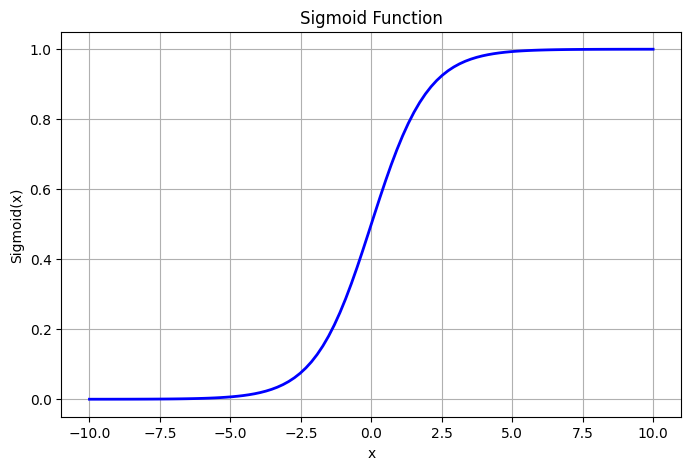

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate x values
x = np.linspace(-10, 10, 100)

# Sigmoid function
y = 1 / (1 + np.exp(-x))

# Plot
plt.figure(figsize=(8,5))
plt.plot(x, y, color='blue', linewidth=2)

plt.title("Sigmoid Function")
plt.xlabel("x")
plt.ylabel("Sigmoid(x)")
plt.grid(True)

plt.show()

### Impact with the sigmoid function

$$
W_n = W_0+\eta(y_i-\hat{y_i})x_i \\
y_i  = \sigma(z)\\
where z=\sum_{i=1}^{n}(w_ix_i)
$$

|$y_i$|$\hat{y_i}$|$y_i-\hat{y_i}$|
------|-----------|---------------|
1|0.8|0.2|
0|0.65|-0.65|
1|0.3|0.7|
0|0.15|-0.15|


# Logistic Regression Weight Update

## Weight Update Rule

$$
\mathbf{w}_{new}
=
\mathbf{w}_{old}
+
\eta\left(y_i-\hat{y}_i\right)\mathbf{x}_i
$$

where

- $\eta$ = Learning Rate
- $y_i$ = Actual Label
- $\hat{y}_i$ = Predicted Probability
- $\mathbf{x}_i$ = Feature Vector

---

## Prediction

The predicted output is

$$
\hat{y}_i=\sigma(z)
$$

where

$$
z=\sum_{i=0}^{n}w_ix_i
$$

or

$$
z=\mathbf{w}^{T}\mathbf{x}
$$

---

## Sigmoid Function

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

---

## Example 1

Suppose

$$
y_i=1
$$

The model predicts

$$
\hat{y}_i=\sigma(10)=0.6
$$

Hence

$$
y_i-\hat{y}_i
=
1-0.6
=
0.4
$$

The weight update becomes

$$
\boxed{
\mathbf{w}_{new}
=
\mathbf{w}_{old}
+
\eta(0.4)\mathbf{x}_i
}
$$

---

## Example 2

Suppose

$$
y_i=1
$$

The model predicts

$$
\hat{y}_i=\sigma(30)=0.8
$$

Hence

$$
y_i-\hat{y}_i
=
1-0.8
=
0.2
$$

The update becomes

$$
\boxed{
\mathbf{w}_{new}
=
\mathbf{w}_{old}
+
\eta(0.2)\mathbf{x}_i
}
$$

---

## Observation

Since

$$
0.4>0.2
$$

the first prediction is **farther from the true label**, therefore the weights change more.

The second prediction is already close to the correct answer, so the update is smaller.

---

## Convergence

As training progresses,

$$
|y-\hat y|
\longrightarrow
0
$$

Eventually

$$
y=\hat y
$$

Therefore

$$
y-\hat y=0
$$

and

$$
\boxed{
\mathbf{w}_{new}
=
\mathbf{w}_{old}
}
$$

No more weight updates occur.

---

# Decision Boundary Example

```mermaid
flowchart LR
    A["Positive Point<br/>σ(10)=0.6"] --> B["Decision Boundary"]
    C["Positive Point<br/>σ(30)=0.8"] --> B
    D["Negative Point"] --> B
    E["Negative Point"] --> B
```

---

# Graph Used in Logistic Regression

```mermaid
xychart-beta
    title "Sigmoid Function"

    x-axis -10 --> 10

    y-axis "Probability" 0 --> 1

    line [0.00005,0.00012,0.00033,0.00091,0.0025,0.0067,0.018,0.047,0.119,0.269,0.5,0.731,0.881,0.953,0.982,0.993,0.997,0.9991,0.9997,0.9999,1]
```

---

## Final Formula

Prediction

$$
\boxed{
\hat y
=
\sigma(\mathbf{w}^T\mathbf{x})
}
$$

Weight Update

$$
\boxed{
\mathbf{w}
=
\mathbf{w}
+
\eta(y-\hat y)\mathbf{x}
}
$$

#### Implimentation of this

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=200,n_features=3,n_informative=1,n_redundant=1,n_clusters_per_class=1,class_sep=3,n_classes=2,random_state=7
                          
)

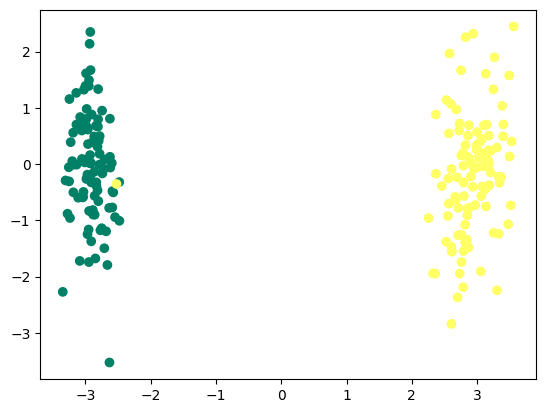

In [ ]:
plt.scatter(X[:,0],X[:,1],c=y,cmap='summer')


In [ ]:
def sigmod(z):
    return 1/(1+np.exp(-z))

In [ ]:
def newPerception(X,y):
    X=np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr =0.1
    for i in range(1000):
        j = np.random.randint(0,200)
        y_hat = sigmod(np.dot(X[j],weights))
        weights  = weights-lr*(y[j]-y_hat)*X[j]
    return weights[0],weights[1:]

In [ ]:
intercept_,coeff_=newPerception(X,y)

/tmp/ipykernel_270356/1056478172.py:2: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-z))


In [ ]:
m_new = -(coeff_[0]/coeff_[1])
b_new = -(intercept_/coeff_[1])

In [ ]:
X_input_2 =np.linspace(-3,3,100)
y_input_2 = m*X_input_2+b_new

In [ ]:
from sklearn.linear_model import LogisticRegression
model2 = LogisticRegression()
model2.fit(X,y)
coeff_new = model2.coef_[0]
intercept_new = model2.intercept_

In [ ]:
print(coeff_new)
print(intercept_new)

[ 0.95234299 -0.10341205  0.98135244]
[1.13502627]


In [ ]:
m_new2 = -(coeff_new[0]/coeff_new[1])
b_new2 = -(intercept_new/coeff_new[1])

In [ ]:
X_input3 = np.linspace(-5,5,200)
Y_input3 = m_new2*X_input3+b_new2


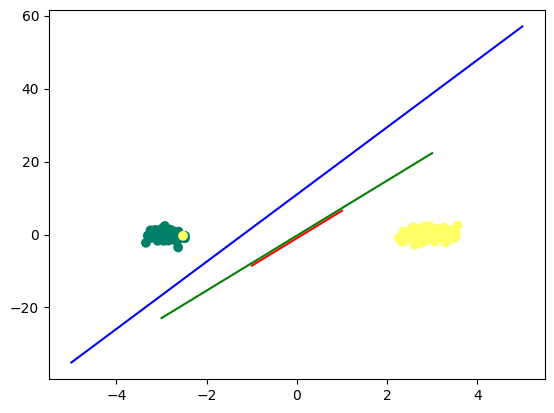

In [ ]:
plt.scatter(X[:,0],X[:,1],c=y,cmap='summer')
plt.plot(X_input,y_input,color = 'red') # perceptron
plt.plot(X_input3,Y_input3,color = 'blue') # sklearn
plt.plot(X_input_2,y_input_2,color='green') # sigmoid

### This is better than the Previous model but still it is not same

### we cannot tell that this is the best  solution because we are randomly selecting the points  and pulling and pushing it respectively since we are selecting the points randomly so in other iteration we may find the other solution which may better o r even worse so the method is to find the loss fucnction

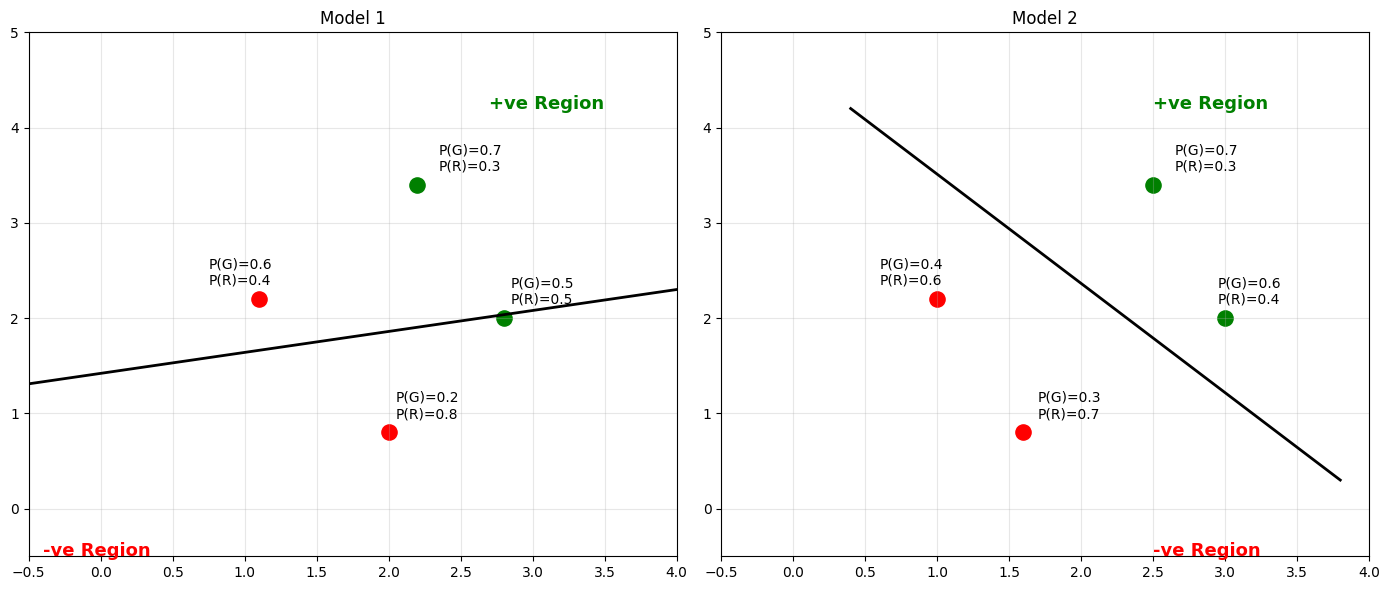

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# =======================
# Model 1
# =======================

plt.subplot(1,2,1)

# Decision Boundary
plt.plot([-1,4],[1.2,2.3],color='black',linewidth=2)

# Positive Points
plt.scatter([2.2,2.8],[3.4,2.0],color='green',s=120)

# Negative Points
plt.scatter([1.1,2.0],[2.2,0.8],color='red',s=120)

# Probability Labels
plt.text(2.35,3.55,"P(G)=0.7\nP(R)=0.3",fontsize=10)

plt.text(0.75,2.35,"P(G)=0.6\nP(R)=0.4",fontsize=10)

plt.text(2.85,2.15,"P(G)=0.5\nP(R)=0.5",fontsize=10)

plt.text(2.05,0.95,"P(G)=0.2\nP(R)=0.8",fontsize=10)

# Region Labels
plt.text(2.7,4.2,"+ve Region",
         color='green',
         fontsize=13,
         weight='bold')

plt.text(-0.4,-0.5,"-ve Region",
         color='red',
         fontsize=13,
         weight='bold')

plt.xlim(-0.5,4)
plt.ylim(-0.5,5)

plt.title("Model 1")

plt.grid(alpha=0.3)



# =======================
# Model 2
# =======================

plt.subplot(1,2,2)

# Decision Boundary
plt.plot([0.4,3.8],[4.2,0.3],color='black',linewidth=2)

# Positive Points
plt.scatter([2.5,3.0],[3.4,2.0],color='green',s=120)

# Negative Points
plt.scatter([1.0,1.6],[2.2,0.8],color='red',s=120)

# Probability Labels
plt.text(2.65,3.55,"P(G)=0.7\nP(R)=0.3",fontsize=10)

plt.text(2.95,2.15,"P(G)=0.6\nP(R)=0.4",fontsize=10)

plt.text(0.6,2.35,"P(G)=0.4\nP(R)=0.6",fontsize=10)

plt.text(1.7,0.95,"P(G)=0.3\nP(R)=0.7",fontsize=10)

# Region Labels
plt.text(2.5,4.2,"+ve Region",
         color='green',
         fontsize=13,
         weight='bold')

plt.text(2.5,-0.5,"-ve Region",
         color='red',
         fontsize=13,
         weight='bold')

plt.xlim(-0.5,4)
plt.ylim(-0.5,5)

plt.title("Model 2")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

#### What we does that the we multiply the probabilities of the model then the model whose poduct of probalilities is maximum is the better model this is called maximum likelyhood
- One important point that if in reality if it is green then we will calculate the probabilty of green and vise versa
- Then there is a problem that we have to multiply the smaller numbers so  this becomes computational less efficent 
- to prevent this we apply log due to which it becomes summation


Mathematically, for discrete distributions, it is defined as: H(p,q)=−∑ 
x
​
 p(x)logq(x)

- we cannot simply multiply with the probability because if it is green then we have to take the  probability of green and if it is red then we have  to take the probabily of red

- from the second model the output will be
- -log(abcd) = -log(0.4)-log(0.7)-log(0.8)-log(0.5)
- for that we  will do a transformation that we will do $-y_iP(y_i)-(1-y_i)P(1-y_i)$
- for the maximum resut we have to minimize the log function

$$
L = \sum_{i=1}^{n}(-y_ilog(\hat{y_i})-(1-y_i)log(1-\hat{y_i}))
$$

$$
\textbf{log loss Error or  Binary Entropy function}
$$

$$
\textbf{we are finding the differentiation of } \frac{d}{dx}[\frac{1}{1+e^\text{-x}}]\\
= \frac{e^\text{-x}}{(1+e^\text{-x})(1+e^\text{-x})}\\
\textbf{After replacing we will get}\\
= \boxed{\sigma(x)[1-\sigma(x)]}
$$

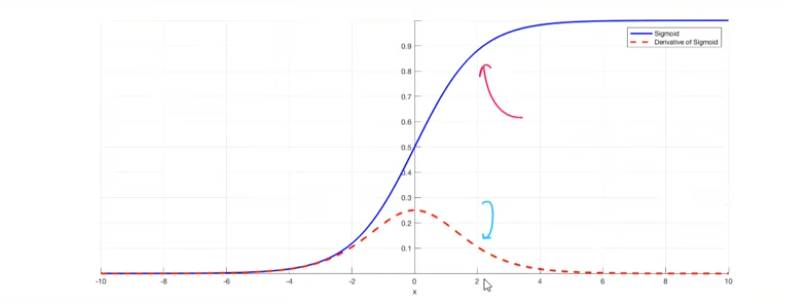

### Now we will apply the gradient descent on our loss function to impliment the Sigmoid Function

# Dataset Representation

Suppose we have:

- **Rows = \(m\)** → Number of training examples (samples)
- **Columns = \(n\)** → Number of features

$$
\begin{array}{c|cccc|c}
 & 1 & 2 & 3 & \cdots & n \\ \hline
1 & X_{11} & X_{12} & X_{13} & \cdots & X_{1n} & Y_{1} \\
2 & X_{21} & X_{22} & X_{23} & \cdots & X_{2n} & Y_{2} \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots & \vdots \\
m & X_{m1} & X_{m2} & X_{m3} & \cdots & X_{mn} & Y_{m}
\end{array}
$$

Where:

- **Rows (\(m\))** = Number of training examples.
- **Columns (\(n\))** = Number of input features.
- \(X_{ij}\) = Value of the **\(j^{th}\)** feature of the **\(i^{th}\)** training example.
- \(Y_i\) = Target (label) corresponding to the **\(i^{th}\)** training example.

The feature matrix is

$$
X =
\begin{bmatrix}
X_{11} & X_{12} & X_{13} & \cdots & X_{1n} \\
X_{21} & X_{22} & X_{23} & \cdots & X_{2n} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
X_{m1} & X_{m2} & X_{m3} & \cdots & X_{mn}
\end{bmatrix}
$$

The target vector is

$$
Y =
\begin{bmatrix}
Y_1 \\
Y_2 \\
\vdots \\
Y_m
\end{bmatrix}
$$

# Vectorized Form of Logistic Regression

For the first training example,

$$
\hat{y}_1=\sigma\left(w_1x_{11}+w_2x_{12}+w_3x_{13}+\cdots+w_nx_{1n}+w_0\right)
$$

For the second training example,

$$
\hat{y}_2=\sigma\left(w_1x_{21}+w_2x_{22}+w_3x_{23}+\cdots+w_nx_{2n}+w_0\right)
$$

Similarly,

$$
\hat{y}_i=\sigma\left(w_1x_{i1}+w_2x_{i2}+w_3x_{i3}+\cdots+w_nx_{in}+w_0\right)
$$

For all the training examples together,

$$
\hat{Y}=
\begin{bmatrix}
\hat{y}_1\\
\hat{y}_2\\
\vdots\\
\hat{y}_m
\end{bmatrix}
=
\begin{bmatrix}
\sigma\left(w_0+w_1x_{11}+w_2x_{12}+\cdots+w_nx_{1n}\right)\\
\sigma\left(w_0+w_1x_{21}+w_2x_{22}+\cdots+w_nx_{2n}\right)\\
\vdots\\
\sigma\left(w_0+w_1x_{m1}+w_2x_{m2}+\cdots+w_nx_{mn}\right)
\end{bmatrix}
$$

where

- \(w_0\) is the **bias (intercept)**.
- \(w_1,w_2,\ldots,w_n\) are the **weights** corresponding to each feature.
- \(\sigma(\cdot)\) is the **sigmoid function**,

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

where

$$
z=w_0+w_1x_1+w_2x_2+\cdots+w_nx_n.
$$

# Matrix Representation of Logistic Regression

Previously, we wrote

$$
\hat{Y}=
\begin{bmatrix}
\hat{y}_1\\
\hat{y}_2\\
\vdots\\
\hat{y}_m
\end{bmatrix}
=
\sigma\left(
\begin{bmatrix}
w_0+w_1x_{11}+w_2x_{12}+\cdots+w_nx_{1n}\\
w_0+w_1x_{21}+w_2x_{22}+\cdots+w_nx_{2n}\\
\vdots\\
w_0+w_1x_{m1}+w_2x_{m2}+\cdots+w_nx_{mn}
\end{bmatrix}
\right)
$$

Notice that each expression is simply the **dot product** of a feature vector and the weight vector.

So we can rewrite it as

$$
\hat{Y}
=
\sigma
\left(
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1n}\\
1 & x_{21} & x_{22} & \cdots & x_{2n}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{m1} & x_{m2} & \cdots & x_{mn}
\end{bmatrix}
\begin{bmatrix}
w_0\\
w_1\\
\vdots\\
w_n
\end{bmatrix}
\right)
$$

Let

$$
X=
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1n}\\
1 & x_{21} & x_{22} & \cdots & x_{2n}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{m1} & x_{m2} & \cdots & x_{mn}
\end{bmatrix}
$$

and

$$
W=
\begin{bmatrix}
w_0\\
w_1\\
\vdots\\
w_n
\end{bmatrix}
$$

Therefore, the entire logistic regression model can be written compactly as

$$
\boxed{\hat{Y}=\sigma(XW)}
$$

where

- \(X\) is the **design matrix** (with the first column of ones for the bias).
- \(W\) is the **weight vector**.
- \(\sigma(\cdot)\) is applied **element-wise** to every element of the vector \(XW\).

The intermediate vector before applying the sigmoid function is called the **logits** or **linear scores**:

$$
Z=XW
$$

Hence,

$$
\boxed{\hat{Y}=\sigma(Z)=\sigma(XW)}
$$

$$
L = \sum_{i=1}^{n}(-y_ilog(\hat{y_i})-(1-y_i)log(1-\hat{y_i})) \\
L = -\frac{1}{m}[\sum_{i=1}^{n}(y_ilog(\hat{y_i}))+\sum_{i=1}^{n}(1-y_i)log(1-\hat{y_i})]
$$



# Binary Cross-Entropy (Log Loss)

The cost function for Logistic Regression is

$$
L
=
-\frac{1}{m}
\left[
\sum_{i=1}^{m} y_i\log(\hat{y}_i)
+
\sum_{i=1}^{m}(1-y_i)\log(1-\hat{y}_i)
\right]
$$

---

## Expanding the First Summation

The first summation is

$$
\sum_{i=1}^{m} y_i\log(\hat{y}_i)
$$

Expanding it,

$$
=
y_1\log(\hat{y}_1)
+
y_2\log(\hat{y}_2)
+
y_3\log(\hat{y}_3)
+\cdots+
y_m\log(\hat{y}_m)
$$

This can be written as the dot product of two vectors:

$$
\begin{bmatrix}
y_1 & y_2 & y_3 & \cdots & y_m
\end{bmatrix}
\begin{bmatrix}
\log(\hat{y}_1)\\
\log(\hat{y}_2)\\
\log(\hat{y}_3)\\
\vdots\\
\log(\hat{y}_m)
\end{bmatrix}
$$

or equivalently,

$$
Y^{T}\log(\hat{Y})
$$

where

$$
Y=
\begin{bmatrix}
y_1\\
y_2\\
\vdots\\
y_m
\end{bmatrix},
\qquad
\log(\hat{Y})=
\begin{bmatrix}
\log(\hat{y}_1)\\
\log(\hat{y}_2)\\
\vdots\\
\log(\hat{y}_m)
\end{bmatrix}
$$

Hence,

$$
\boxed{
\sum_{i=1}^{m} y_i\log(\hat{y}_i)
=
Y^{T}\log(\sigma(XW))
}
$$

# Vectorized Binary Cross-Entropy Loss

The Binary Cross-Entropy (Log Loss) for Logistic Regression can be written as

$$
L
=
-\frac{1}{m}
\left[
Y^{T}\log(\hat{Y})
+
(1-Y)^{T}\log(1-\hat{Y})
\right]
$$

where

$$
\hat{Y}=\sigma(XW)
$$

The sigmoid function is

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

Since

$$
Z=XW,
$$

we can also write

$$
\hat{Y}=\sigma(Z).
$$

---

## Definitions

$$
Y=
\begin{bmatrix}
y_1\\
y_2\\
\vdots\\
y_m
\end{bmatrix},
\qquad
\hat{Y}=
\begin{bmatrix}
\hat{y}_1\\
\hat{y}_2\\
\vdots\\
\hat{y}_m
\end{bmatrix}
$$

$$
X=
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1n}\\
1 & x_{21} & x_{22} & \cdots & x_{2n}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{m1} & x_{m2} & \cdots & x_{mn}
\end{bmatrix},
\qquad
W=
\begin{bmatrix}
w_0\\
w_1\\
\vdots\\
w_n
\end{bmatrix}
$$

Thus,

$$
\boxed{
L
=
-\frac{1}{m}
\left[
Y^{T}\log(\sigma(XW))
+
(1-Y)^{T}\log(1-\sigma(XW))
\right]
}
$$

This is the fully vectorized Binary Cross-Entropy loss used in Logistic Regression.

## Now  our task is to find W so that the  value of the loss function is minimum for that we will use the gradient descent
- We will init with any values then we will iterate 
## $$ \boxed{W = W-\eta \frac{\Delta L}{\Delta W}}$$

### The main task  is to find the derivate

# Simplification of the Gradient

Starting from

$$
\frac{\partial L}{\partial W}
=
-\frac{1}{m}
\left[
Y(1-\hat{Y})X
-
\hat{Y}(1-Y)X
\right]
$$

Factor out the common term \(X\),

$$
\frac{\partial L}{\partial W}
=
-\frac{1}{m}
\left[
Y(1-\hat{Y})
-
\hat{Y}(1-Y)
\right]X
$$

Expand the terms,

$$
=
-\frac{1}{m}
\left[
Y-Y\hat{Y}
-\hat{Y}
+\hat{Y}Y
\right]X
$$

Since

$$
-Y\hat{Y}+\hat{Y}Y=0,
$$

the expression becomes

$$
=
-\frac{1}{m}
\left(
Y-\hat{Y}
\right)X
$$

Finally,

$$
\boxed{
\frac{\partial L}{\partial W}
=
-\frac{1}{m}(Y-\hat{Y})X
}
$$

or equivalently,

$$
\boxed{
\frac{\partial L}{\partial W}
=
-\frac{1}{m}(Y-\hat{Y})X
}
$$


$$
\boxed{W=W+\eta\frac{1}{m}(y-\hat{y})X}
$$

In [ ]:
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=200, n_features=2,n_informative=2,n_redundant=0,n_clusters_per_class=1,random_state=5)


In [ ]:
print(X.shape)

(200, 2)


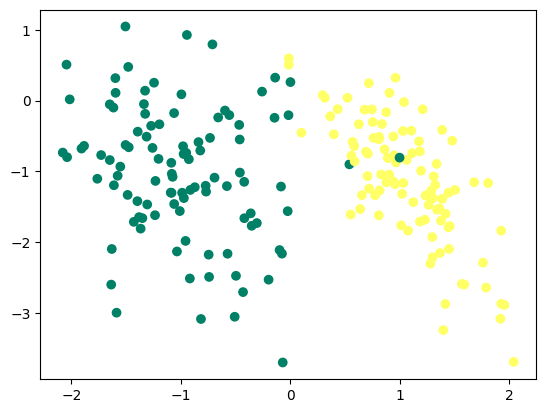

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1],c=y,cmap='summer')

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test  = train_test_split(X,y,test_size=0.25)
from sklearn.metrics import r2_score

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(penalty=None,solver='sag')
model.fit(X_train,y_train)
out = model.predict(X_test)
print(r2_score(y_test,out))
intercept_ = model.intercept_
coeff_ = model.coef_[0]


1.0


/home/darshchouhan/.local/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [ ]:
print(intercept_)

[-0.39110491]


In [ ]:
print(coeff_)

[6.92097561 1.76521655]


In [ ]:
m= -coeff_[0]/coeff_[1]
c = -intercept_/coeff_[1]

In [ ]:
print(m)
print(c[0])
print(m_my)
print(c_my)

-3.9207516061206427
0.22156200126996434
-4.340481510557456
0.20690065041370959


In [ ]:
X_input = np.linspace(X[:,0].min(),X[:,0].max(),200)
y_out  = m*X_input+c[0]

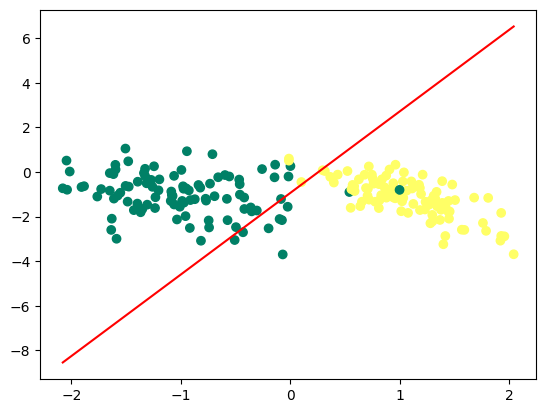

In [ ]:
plt.scatter(X[:,0],X[:,1],c=y,cmap='summer')
plt.plot(X_input,y_input,color='red')

In [ ]:

class LogisticReg():
    def __init__(self,lr=0.01 ,epochs=1000):
        self.lr=lr
        self.epochs=epochs
        self.intercept_=None
        self.coeff_=None
    def sigmoid(self,z):
        return 1/(1+np.exp(-z))
    def fit(self,X,y):
        X=np.insert(X,0,1,axis=1)
        weights = np.ones(X.shape[1])
        for i in range(self.epochs):
            y_hat=self.sigmoid(np.dot(X,weights))
            weights = weights+self.lr*(np.dot(y-y_hat,X)/X.shape[0])
        self.intercept_=weights[0]
        self.coeff_=weights[1:]
    def predict(self,X_test):
        z= np.dot(X_test,self.coeff_)+self.intercept_
        y_hat= self.sigmoid(z)
        return np.where(y_hat>=0.5,1,0)


In [ ]:
LogReg =  LogisticReg()
LogReg.fit(X_train,y_train)
print(LogReg.intercept_)
print(LogReg.coeff_)


0.6996154370406109
[2.31321337 0.75306939]


In [ ]:
import pandas as pd

In [ ]:
coeff_my = LogReg.coeff_
intercept_my = LogReg.intercept_

In [ ]:
print(coeff_my)
print(intercept_my)
print(coeff_)
print(intercept_)

[2.31321337 0.75306939]
0.6996154370406109
[6.92097561 1.76521655]
[-0.39110491]


In [ ]:
from sklearn.metrics import accuracy_score
out=LogReg.predict(X_test)
print(accuracy_score(y_test,out))

1.0


In [ ]:
m_my= -coeff_my[0]/coeff_my[1]
c_my = -intercept_my/coeff_my[1]

In [ ]:
c_my

np.float64(-0.929018555431825)

In [ ]:

y_out_my  = m_my*X_input+c_my

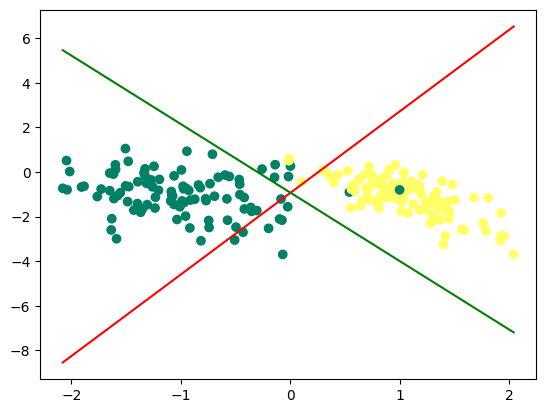

In [ ]:
plt.scatter(X[:,0],X[:,1],c=y,cmap='summer')
plt.plot(X_input,y_input,color='red')
plt.plot(X_input,y_out_my,color='green')

In [ ]:
print(LogReg.intercept_)
print(LogReg.coeff_)

print(model.intercept_)
print(model.coef_)

-0.2887162744284634
[6.05685699 1.39543435]
[-0.39110491]
[[6.92097561 1.76521655]]
